#### Create Dataset

In [92]:
from sklearn.datasets import make_circles
import torch
N_SAMPLE = 1000
RANDOM_STATE = 42

X , y = make_circles(n_samples=N_SAMPLE,
             random_state=RANDOM_STATE,
             noise=0.03)

X,y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)

X,y

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         ...,
         [-0.1369, -0.8100],
         [ 0.6704, -0.7675],
         [ 0.2811,  0.9638]]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1.,
         1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0.,
         1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
         0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0.,
         1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0.,
         0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
         0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1.,
         1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
         1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
         1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.,


In [93]:
# visualize using pandas
import pandas as pd

pd.DataFrame({"X1" : X[:, 0], "X2": X[:,1], "y": y})


,X1,X2,y
0,0.754246,0.231481,1.0
1,-0.756159,0.153259,1.0
2,-0.815392,0.173282,1.0
3,-0.393731,0.692883,1.0
4,0.442208,-0.896723,0.0
...,...,...,...
995,0.244054,0.944125,0.0
996,-0.978655,-0.272373,0.0
997,-0.136900,-0.810012,1.0
998,0.670362,-0.767502,0.0


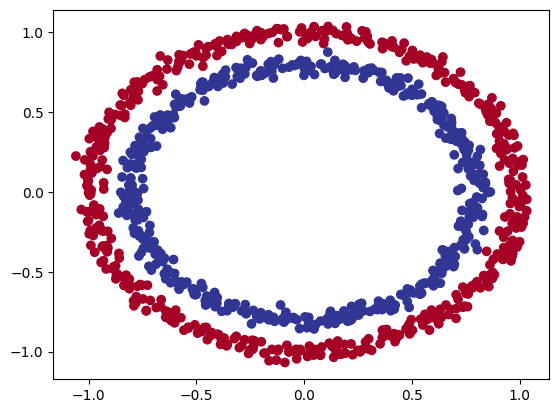

In [94]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdYlBu")

In [95]:
import torch
from torch import nn

class ClassficationV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
        
    def forward(self, input):
        return self.layer_2(self.layer_1(input))

        

In [96]:
model_1 = ClassficationV1()

model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.4891, -0.4724],
                      [-0.5060, -0.2734],
                      [-0.0657, -0.5691],
                      [ 0.4848,  0.0950],
                      [-0.6067,  0.6431]])),
             ('layer_1.bias',
              tensor([ 0.3774, -0.3598, -0.1530,  0.5745,  0.2434])),
             ('layer_2.weight',
              tensor([[-0.4369,  0.1053, -0.3353,  0.0351, -0.2217]])),
             ('layer_2.bias', tensor([0.0771]))])

In [97]:
from torchinfo import summary

summary(model_1)

Layer (type:depth-idx)                   Param #
ClassficationV1                          --
├─Linear: 1-1                            15
├─Linear: 1-2                            6
Total params: 21
Trainable params: 21
Non-trainable params: 0

In [98]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)

len(X_test)

200

In [129]:
from helpers import accuracy_fn
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01)

#training loop
epochs = 100

for epoch in range(epochs):
    model_1.train()
    # forward pass
    
    # logits ---> pred prob =---> pred label
    train_logits = model_1(X_train).squeeze()
    pred_prob = torch.sigmoid(train_logits)
    pred_label = torch.round(pred_prob)
    # calc the loss
    train_loss = loss_fn(train_logits, y_train)
    
    optimizer.zero_grad()
    
    train_loss.backward()
    optimizer.step()
    
    model_1.eval()

    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        
        if epoch%10 == 0:
            train_acc = accuracy_fn(y_train, pred_label)
            test_acc = accuracy_fn(y_test, test_pred)


            print(f"Epoch : {epoch} | train_loss : {train_loss} | test_loss : {test_loss}, | train_acc : {train_acc} | test_acc: {test_acc}")
        
        
    
    


Epoch : 0 | train_loss : 0.6970901489257812 | test_loss : 0.7056242227554321, | train_acc : 50.0 | test_acc: 47.5
Epoch : 10 | train_loss : 0.6969714164733887 | test_loss : 0.7054243683815002, | train_acc : 49.875 | test_acc: 48.0
Epoch : 20 | train_loss : 0.6968569755554199 | test_loss : 0.7052295207977295, | train_acc : 49.875 | test_acc: 48.0
Epoch : 30 | train_loss : 0.6967466473579407 | test_loss : 0.7050395011901855, | train_acc : 50.125 | test_acc: 48.5
Epoch : 40 | train_loss : 0.6966402530670166 | test_loss : 0.7048542499542236, | train_acc : 50.125 | test_acc: 48.5
Epoch : 50 | train_loss : 0.6965374946594238 | test_loss : 0.7046734690666199, | train_acc : 50.125 | test_acc: 48.5
Epoch : 60 | train_loss : 0.6964383125305176 | test_loss : 0.7044969201087952, | train_acc : 50.0 | test_acc: 48.5
Epoch : 70 | train_loss : 0.696342408657074 | test_loss : 0.7043245434761047, | train_acc : 50.0 | test_acc: 48.5
Epoch : 80 | train_loss : 0.6962497234344482 | test_loss : 0.70415610074

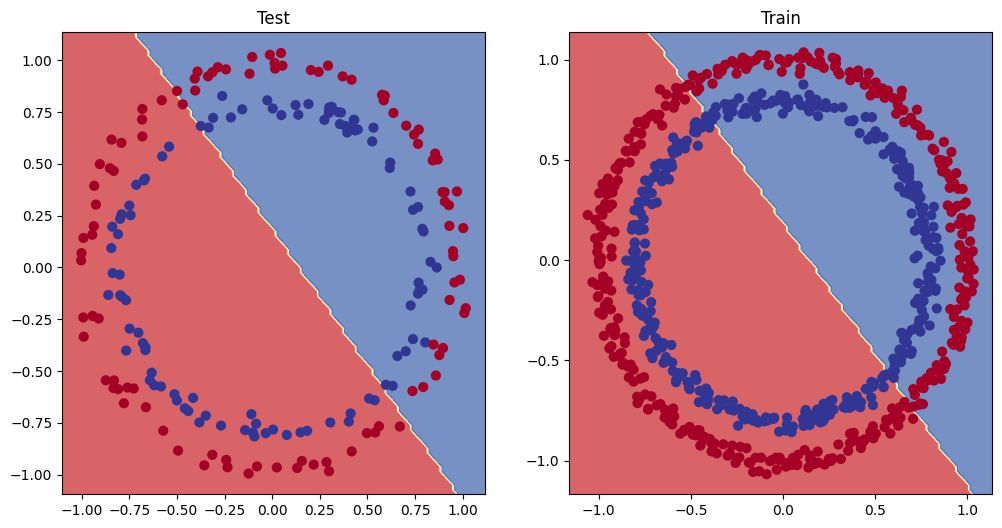

In [134]:
# visulaize
import matplotlib.pyplot as plt
from helpers import plot_decision_boundary

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

plt.subplot(1,2,2)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)



In [176]:
import torch
from torch import nn

class ClassficationV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=2, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=1),      
        )
        
    def forward(self, input):
        return self.layers(input)


In [177]:
model_2 = ClassficationV2()

model_2

ClassficationV2(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [180]:
from helpers import accuracy_fn
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

#training loop
epochs = 1000

for epoch in range(epochs):
    model_2.train()
    # forward pass
    
    # logits ---> pred prob =---> pred label
    train_logits = model_2(X_train).squeeze()
    pred_prob = torch.sigmoid(train_logits)
    pred_label = torch.round(pred_prob)
    # calc the loss
    train_loss = loss_fn(train_logits, y_train)
    
    optimizer.zero_grad()
    
    train_loss.backward()
    optimizer.step()
    
    model_2.eval()

    with torch.inference_mode():
        test_logits = model_2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        
        if epoch%10 == 0:
            train_acc = accuracy_fn(y_train, pred_label)
            test_acc = accuracy_fn(y_test, test_pred)


            print(f"Epoch : {epoch} | train_loss : {train_loss} | test_loss : {test_loss}, | train_acc : {train_acc} | test_acc: {test_acc}")
        
        
    
    


Epoch : 0 | train_loss : 0.4926571547985077 | test_loss : 0.5378063321113586, | train_acc : 92.5 | test_acc: 86.0
Epoch : 10 | train_loss : 0.48266586661338806 | test_loss : 0.5289435386657715, | train_acc : 92.625 | test_acc: 86.5
Epoch : 20 | train_loss : 0.47211363911628723 | test_loss : 0.5193834900856018, | train_acc : 93.75 | test_acc: 86.5
Epoch : 30 | train_loss : 0.4613185226917267 | test_loss : 0.5092845559120178, | train_acc : 94.25 | test_acc: 89.5
Epoch : 40 | train_loss : 0.45014485716819763 | test_loss : 0.4987109899520874, | train_acc : 94.875 | test_acc: 90.5
Epoch : 50 | train_loss : 0.43858638405799866 | test_loss : 0.4876690208911896, | train_acc : 95.25 | test_acc: 91.0
Epoch : 60 | train_loss : 0.4267338514328003 | test_loss : 0.4763551354408264, | train_acc : 95.75 | test_acc: 91.5
Epoch : 70 | train_loss : 0.41457995772361755 | test_loss : 0.46470195055007935, | train_acc : 96.75 | test_acc: 92.0
Epoch : 80 | train_loss : 0.4021557569503784 | test_loss : 0.45261

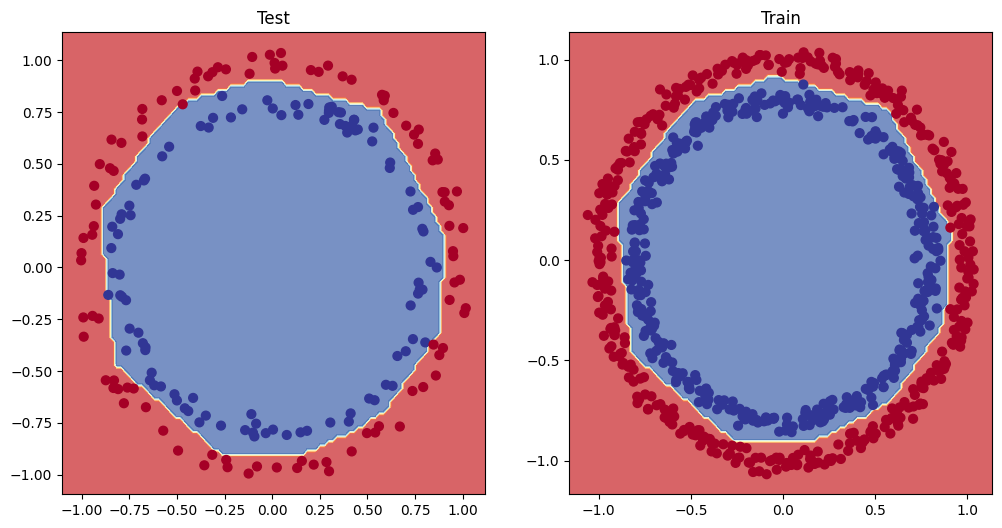

In [181]:
# visualize
# visulaize
import matplotlib.pyplot as plt
from helpers import plot_decision_boundary

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)

plt.subplot(1,2,2)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)

